In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

long_df = pd.read_csv("protein_rightligand_interaction2.0.csv")

residue_columns = [col for col in long_df.columns if col not in ['Ligand', 'Protein']]
long_df_melted = long_df.melt(
    id_vars=['Ligand', 'Protein'],
    value_vars=residue_columns,
    var_name='Residue',
    value_name='InteractionType'
)
long_df_melted = long_df_melted[long_df_melted['InteractionType'] != "0"].reset_index(drop=True)

In [7]:
chembl = pd.read_csv("chembl_ligand_ic50.csv")

chembl['IC50_nM'] = pd.to_numeric(chembl['IC50_nM'], errors='coerce')

chembl['pIC50'] = -np.log10(chembl['IC50_nM'] * 1e-9)

chembl = chembl[['Ligand', 'pIC50']].dropna()

In [11]:
merged = pd.merge(
    long_df_melted,
    chembl,
    on='Ligand',
    how='inner'  # только те лиганды, для которых есть pIC50
)

print(f"Всего взаимодействий с pIC50: {len(merged)}")

Всего взаимодействий с pIC50: 435


In [13]:
merged['PotencyGroup'] = merged['pIC50'].apply(
    lambda x: 'High (pIC50 ≥ 7)' if x >= 7.0 else 'Low'
)

In [14]:
residue_counts = (
    merged
    .groupby(['Residue', 'PotencyGroup'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for group in ['High (pIC50 ≥ 7)', 'Low']:
    if group not in residue_counts.columns:
        residue_counts[group] = 0

residue_counts['Total'] = residue_counts['High (pIC50 ≥ 7)'] + residue_counts['Low']
residue_counts = residue_counts.sort_values('Total', ascending=False).drop(columns='Total')

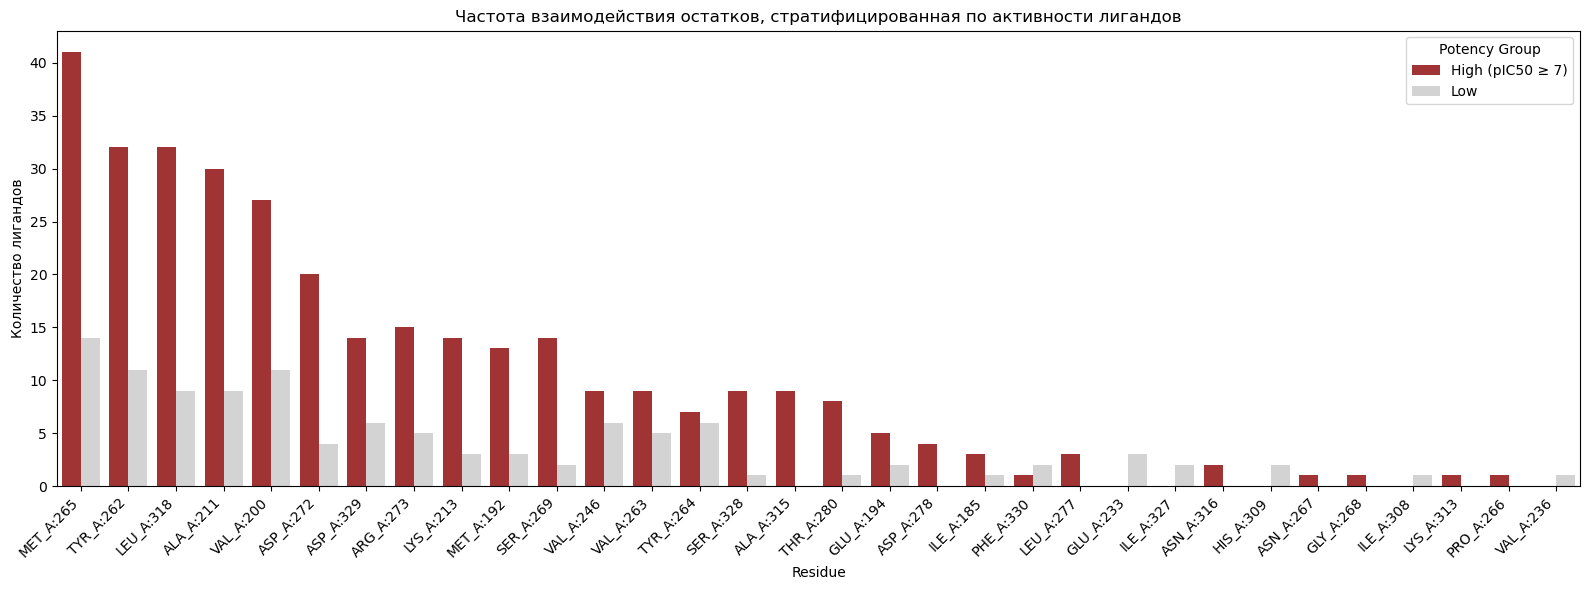

In [20]:
plot_data = residue_counts.melt(
    id_vars='Residue',
    value_vars=['High (pIC50 ≥ 7)', 'Low'],
    var_name='Potency Group',
    value_name='Interaction Count'
)

plt.figure(figsize=(16, 6))
sns.barplot(
    data=plot_data,
    x='Residue',
    y='Interaction Count',
    hue='Potency Group',
    palette={'High (pIC50 ≥ 7)': 'firebrick', 'Low': 'lightgray'}
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Количество лигандов')
plt.title('Частота взаимодействия остатков, стратифицированная по активности лигандов')
plt.tight_layout()
plt.savefig("residue_IC50_barplot.png", dpi=300, bbox_inches='tight')
plt.show()